# SVM Demo with Hyperparameter Search

This notebook compares:
- Linear SVM
- RBF Kernel SVM
- Polynomial Kernel SVM

using the **Breast Cancer Wisconsin** dataset from scikit-learn.

It includes:
- train/test split
- standardization
- baseline comparison
- **GridSearchCV** hyperparameter tuning
- confusion matrices
- classification reports
- summary tables


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


## 1. Load the dataset


In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print('Dataset shape:', X.shape)
print('Target names:', data.target_names)
print('Class counts:', np.bincount(y))

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()


Dataset shape: (569, 30)
Target names: ['malignant' 'benign']
Class counts: [212 357]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Train/test split


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)


Training set: (426, 30)
Test set: (143, 30)


## 3. Baseline models

Standardization is important for SVM, so each model is wrapped in a pipeline.


In [4]:
baseline_models = {
    'Linear SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', C=1.0))
    ]),

    'RBF Kernel SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
    ]),

    'Polynomial Kernel SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='poly', degree=3, C=1.0, gamma='scale'))
    ])
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    baseline_results.append({
        'Model': name,
        'Test Accuracy': acc,
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
baseline_df = pd.DataFrame(baseline_results).sort_values(by='CV Mean Accuracy', ascending=False)
baseline_df


,Model,Test Accuracy,CV Mean Accuracy,CV Std
0,Linear SVM,0.986014,0.964761,0.012938
1,RBF Kernel SVM,0.979021,0.964733,0.022351
2,Polynomial Kernel SVM,0.902098,0.894282,0.029020


## 4. Hyperparameter search with GridSearchCV

### We tune each kernel separately.
#### In soft margin SVM (C): 0 < alpha_i< C
#### In Gaussian kernel (gamma γ) : K(x,x′)=exp(−γ|x−x′|^2), γ=1/(2σ^2)


In [5]:
search_spaces = {
    'Linear SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='linear'))
        ]),
        'params': {
            'svm__C': [0.01, 0.1, 1, 10, 100]
        }
    },

    'RBF Kernel SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='rbf'))
        ]),
        'params': {
            'svm__C': [0.1, 1, 10, 100],
            'svm__gamma': ['scale', 0.001, 0.01, 0.1, 1] #γ=1/(d⋅Var(X)), "scale" adjusts gamma to match the dataset, often wins
        }
    },

    'Polynomial Kernel SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='poly'))
        ]),
        'params': {
            'svm__C': [0.1, 1, 10, 100],
            'svm__degree': [2, 3, 4],
            'svm__gamma': ['scale', 0.001, 0.01, 0.1]
        }
    }
}

best_models = {}
search_summary = []

for name, config in search_spaces.items():
    print('=' * 80)
    print(f'Running GridSearchCV for: {name}')
    
    grid = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    
    y_pred = grid.best_estimator_.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    
    print('Best parameters:', grid.best_params_)
    print(f'Best CV accuracy: {grid.best_score_:.4f}')
    print(f'Test accuracy:    {test_acc:.4f}')
    
    search_summary.append({
        'Model': name,
        'Best Params': str(grid.best_params_),
        'Best CV Accuracy': grid.best_score_,
        'Test Accuracy': test_acc
    })

search_df = pd.DataFrame(search_summary).sort_values(by='Best CV Accuracy', ascending=False)
search_df


Running GridSearchCV for: Linear SVM
Best parameters: {'svm__C': 0.01}
Best CV accuracy: 0.9765
Test accuracy:    0.9580
Running GridSearchCV for: RBF Kernel SVM
Best parameters: {'svm__C': 10, 'svm__gamma': 0.001}
Best CV accuracy: 0.9765
Test accuracy:    0.9790
Running GridSearchCV for: Polynomial Kernel SVM
Best parameters: {'svm__C': 100, 'svm__degree': 3, 'svm__gamma': 'scale'}
Best CV accuracy: 0.9578
Test accuracy:    0.9790


,Model,Best Params,Best CV Accuracy,Test Accuracy
0,Linear SVM,{'svm__C': 0.01},0.976525,0.958042
1,RBF Kernel SVM,"{'svm__C': 10, 'svm__gamma': 0.001}",0.976525,0.979021
2,Polynomial Kernel SVM,"{'svm__C': 100, 'svm__degree': 3, 'svm__gamma'...",0.957784,0.979021


## 5. Evaluate the tuned models


Linear SVM
Test Accuracy: 0.9580

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



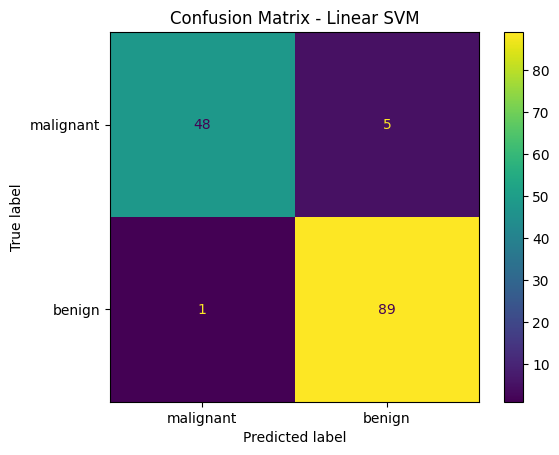

RBF Kernel SVM
Test Accuracy: 0.9790

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.96      0.97        53
      benign       0.98      0.99      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



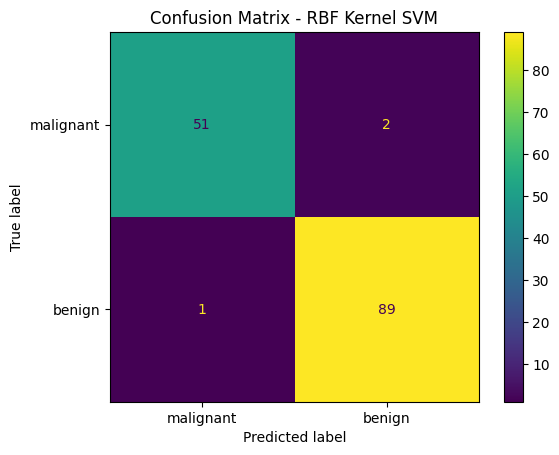

Polynomial Kernel SVM
Test Accuracy: 0.9790

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.96      0.97        53
      benign       0.98      0.99      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



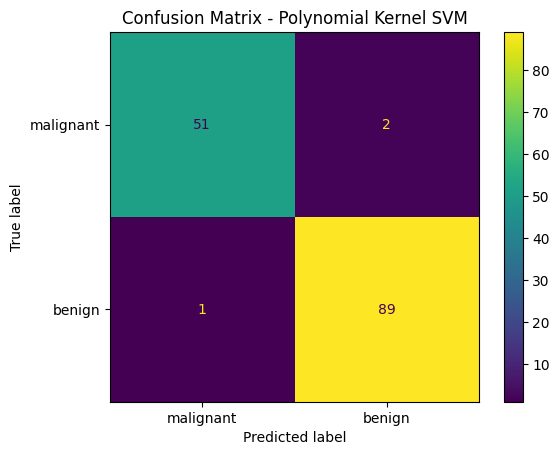

In [6]:
for name, model in best_models.items():
    print('=' * 80)
    print(name)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'Test Accuracy: {acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=data.target_names))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.show()


## 6. Compare baseline vs tuned models


In [7]:
merged = baseline_df[['Model', 'CV Mean Accuracy', 'Test Accuracy']].merge(
    search_df[['Model', 'Best CV Accuracy', 'Test Accuracy']],
    on='Model',
    suffixes=('_Baseline', '_Tuned')
)
merged


,Model,CV Mean Accuracy,Test Accuracy_Baseline,Best CV Accuracy,Test Accuracy_Tuned
0,Linear SVM,0.964761,0.986014,0.976525,0.958042
1,RBF Kernel SVM,0.964733,0.979021,0.976525,0.979021
2,Polynomial Kernel SVM,0.894282,0.902098,0.957784,0.979021


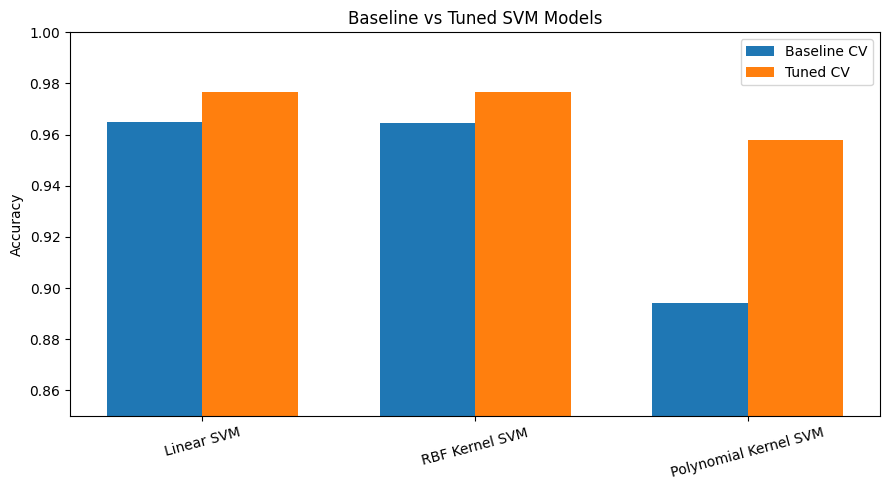

In [8]:
plot_df = pd.DataFrame({
    'Model': search_df['Model'],
    'Baseline CV': baseline_df.set_index('Model').loc[search_df['Model'], 'CV Mean Accuracy'].values,
    'Tuned CV': search_df['Best CV Accuracy'].values
})

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df['Baseline CV'], width, label='Baseline CV')
plt.bar(x + width/2, plot_df['Tuned CV'], width, label='Tuned CV')
plt.xticks(x, plot_df['Model'], rotation=15)
plt.ylim(0.85, 1.0)
plt.ylabel('Accuracy')
plt.title('Baseline vs Tuned SVM Models')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Final remarks

- Linear SVM works well when the boundary is approximately linear.
- RBF kernel is often a strong default choice for nonlinear patterns.
- Polynomial kernel can capture interactions, but may require more tuning.
- Standardization is important before fitting SVM models.
- Grid search helps select good values for **C**, **gamma**, and **degree**.
